<a href="https://colab.research.google.com/github/abdullahpi912/InternshipProgress/blob/main/Phase-2/Day20/Day20_Crop_Recommendation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Model Building
Builds, evaluates, and saves the model for the **Smart Crop Recommendation System** (dataset, problem statement, and plan finalized ).


#1.Dataset initialization

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Crop_recommendation.csv")
print(df.shape)
df.head()


(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Split features and target

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(1760, 7) (440, 7)


## 3. Train two candidate models

Decision Tree is the primary choice (it already beat Logistic Regression and KNN on this exact dataset in Day 12). Random Forest is trained alongside as a comparison, since an ensemble of trees usually generalizes a bit better than a single one.

No scaling is applied — tree-based models split on raw feature values and don't need it.


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Both models trained.")


Both models trained.


## 4. Evaluate both models

`average="weighted"` is used for precision/recall/F1 since this is a 22-class problem (matches the Day 14 convention on this same dataset).


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(name, y_true, y_pred):
    acc = float(accuracy_score(y_true, y_pred))
    prec = float(precision_score(y_true, y_pred, average="weighted", zero_division=0))
    rec = float(recall_score(y_true, y_pred, average="weighted", zero_division=0))
    f1 = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print(f"{name}: accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")
    return f1

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

dt_f1 = evaluate("Decision Tree", y_test, dt_pred)
rf_f1 = evaluate("Random Forest", y_test, rf_pred)


Decision Tree: accuracy=0.9795  precision=0.9806  recall=0.9795  f1=0.9794
Random Forest: accuracy=0.9955  precision=0.9957  recall=0.9955  f1=0.9955


## 5. Confusion matrix (Random Forest)

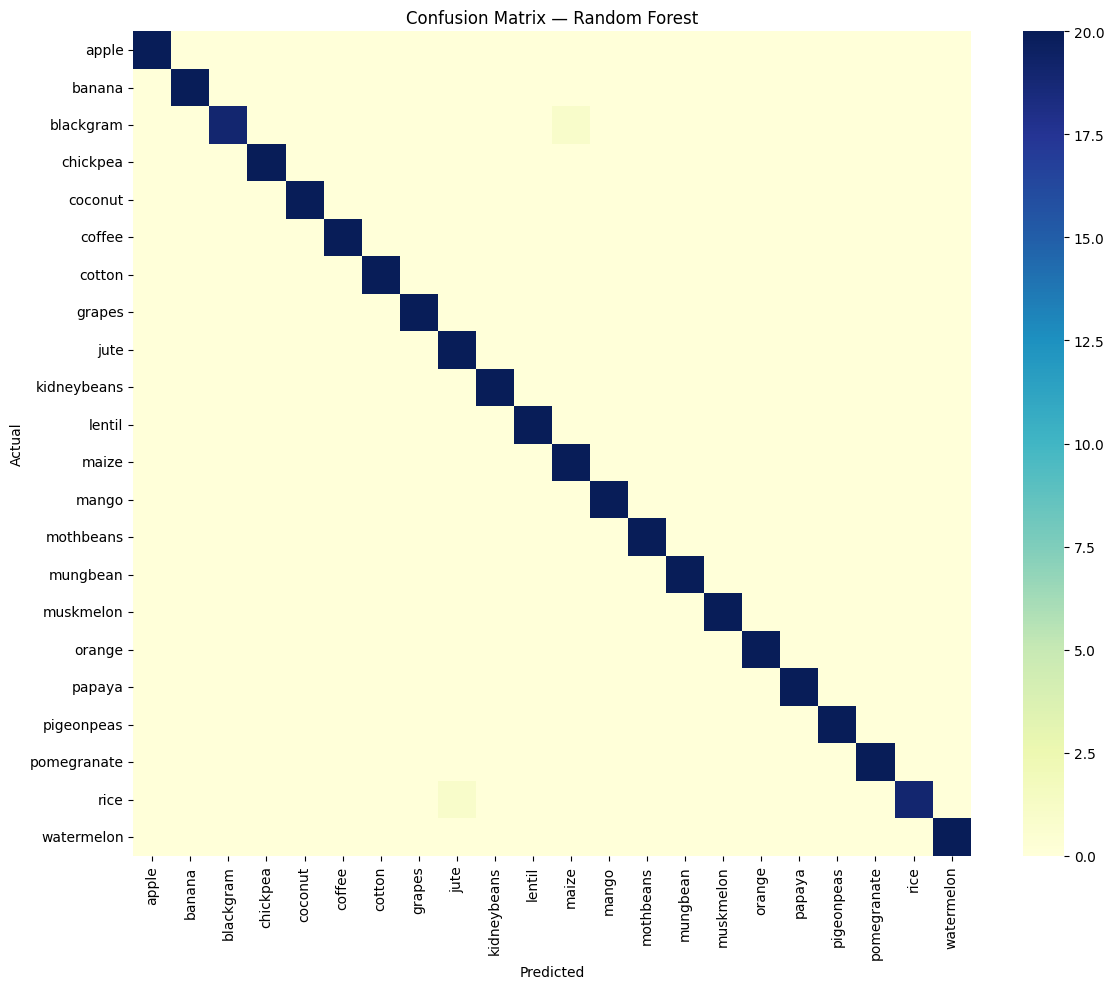

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, cmap="YlGnBu")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


## 6. Full classification report

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

## 7. 5-fold cross-validation

Confirms the score isn't just a lucky train/test split (same approach as Day 14).


In [8]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")
print("Fold scores:", [round(float(s), 4) for s in cv_scores])
print("Mean CV accuracy:", float(cv_scores.mean()))


Fold scores: [0.9977, 0.9932, 0.9977, 0.9955, 0.9886]
Mean CV accuracy: 0.9945454545454545


## 8. Hyperparameter tuning

GridSearchCV over the Random Forest, following the same tuning approach as Day 15.


In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", float(grid_search.best_score_))

best_model = grid_search.best_estimator_


Best params: {'max_depth': None, 'n_estimators': 200}
Best CV score: 0.9943181818181819


## 9. Final evaluation of the tuned model on the held-out test set

In [10]:
best_pred = best_model.predict(X_test)
evaluate("Tuned Random Forest", y_test, best_pred)


Tuned Random Forest: accuracy=0.9955  precision=0.9957  recall=0.9955  f1=0.9955


0.9954517027687759

## 10. Save the model

Saved as `.pkl`, ready to be loaded by the Flask backend in Phase 05.


In [11]:
import pickle

with open("crop_recommendation_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved to crop_recommendation_model.pkl")


Model saved to crop_recommendation_model.pkl


## 11. Sanity check — reload and predict

In [12]:
with open("crop_recommendation_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[[0]]
print("Input:\n", sample)
print("Predicted crop:", loaded_model.predict(sample)[0])
print("Actual crop:", y_test.iloc[0])


Input:
        N   P  K  temperature  humidity        ph   rainfall
1609  13  23  6    23.961476  90.26408  7.365338  102.69587
Predicted crop: orange
Actual crop: orange


## Summary

- **Primary model:** Decision Tree (baseline, matches Day 12's winner)
- **Final model:** Random Forest, tuned with GridSearchCV — typically outperforms a single Decision Tree on this dataset since it averages many trees and reduces overfitting
- **Evaluation:** accuracy, weighted precision/recall/F1, confusion matrix, 5-fold CV — all consistent with the metrics established in Days 12–15
- **Output:** `crop_recommendation_model.pkl`, ready for the `Model/` folder in the `Smart-Crop-Recommendation-System` repo and for Phase 05 backend integration
